# Indian Digital Advertising — Sentiment Analysis
### MBA DS/AI Project | IIT Mandi | 2025

**Problem Statement:**
Indian consumers are increasingly exposed to digital advertising on platforms like YouTube, Instagram, and Hotstar. Despite ₹650B+ being spent on digital ads annually, user frustration is rising. This project analyses Play Store reviews to quantify ad sentiment across major platforms and contextualises findings against 20 years of Indian advertising industry data.

**Research Questions:**
1. Which platform generates the most negative ad sentiment among Indian users?
2. What are the most common complaint themes in negative ad reviews?
3. Does ad sentiment correlate with star ratings?
4. How has digital advertising grown relative to print and TV over 20 years?

**Data Sources:**
- Primary: Google Play Store reviews (scraped via google-play-scraper)

- Secondary: FICCI-EY Media & Entertainment Reports (2005–2024)

In [61]:
# ============================================================
# IMPORTS
# All libraries loaded here — nothing else in this cell
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from google_play_scraper import reviews, Sort
from sklearn.linear_model import LinearRegression
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.family'] = 'sans-serif'
sns.set_style("whitegrid")

print("Done - All libraries loaded successfully")

✅ All libraries loaded successfully


## 1. Data Collection
**Source:** Google Play Store reviews scraped using google-play-scraper  
**Apps:** YouTube, Instagram, Hotstar, MX Player, ShareChat  
**Filter:** Reviews mentioning 'ad', 'ads', or 'advert'  
**Date scraped:** May 2025

In [62]:
# ============================================================
# DATA COLLECTION — Play Store Scraping
# Scraping 1000 reviews per app, filtering for ad-related ones
# ============================================================

apps = [
    {'name': 'YouTube',    'id': 'com.google.android.youtube'},
    {'name': 'Instagram',  'id': 'com.instagram.android'},
    {'name': 'Hotstar',    'id': 'in.startv.hotstar'},
    {'name': 'MX Player',  'id': 'com.mxtech.videoplayer.ad'},
    {'name': 'ShareChat',  'id': 'in.sharechat.sharechatapp'}
]

all_reviews = []

for app in apps:
    print(f"Scraping {app['name']}...")
    try:
        result, _ = reviews(
            app['id'],
            lang='en',
            country='in',
            sort=Sort.MOST_RELEVANT,
            count=1000
        )
        for review in result:
            text = review['content'].lower()
            if any(word in text for word in ['ad ', 'ads', 'advert', 'advertisement']):
                all_reviews.append({
                    'App':      app['name'],
                    'Review':   review['content'],
                    'Rating':   review['score'],
                    'Date':     review['at'],
                    'Source':   'Play Store'
                })
        print(f"  Done - Done — found ad-related reviews")
    except Exception as e:
        print(f"  Error - Error scraping {app['name']}: {e}")

df = pd.DataFrame(all_reviews)
print(f"\nDone - Total ad-related reviews collected: {len(df)}")
df.head()

Scraping YouTube...
  ✅ Done — found ad-related reviews
Scraping Instagram...
  ✅ Done — found ad-related reviews
Scraping Hotstar...
  ✅ Done — found ad-related reviews
Scraping MX Player...
  ✅ Done — found ad-related reviews
Scraping ShareChat...
  ✅ Done — found ad-related reviews

✅ Total ad-related reviews collected: 1970


,App,Review,Rating,Date,Source
0,YouTube,1. Closed captions don't show up now in the la...,2,2026-02-24 23:17:35,Play Store
1,YouTube,The app is still one star... you guys still ha...,1,2026-05-04 13:28:32,Play Store
2,YouTube,Every 5 minutes the ads will come. That's very...,1,2026-05-08 11:22:20,Play Store
3,YouTube,"i accidentally tapped a link, and guess what? ...",5,2026-05-20 23:09:13,Play Store
4,YouTube,"Its not YouTube anymore , it's AdTube now , un...",1,2026-05-18 10:14:06,Play Store


In [63]:
# ============================================================
# DATA COLLECTION — Extended scraping with broader keywords
# Capturing perception of streaming, content interruption,
# skippable ads, brand ads, and overall ad experience
# ============================================================

keywords = [
    'ad ', 'ads', 'advert', 'advertisement',
    'commercial', 'sponsor', 'promoted',
    'skip', 'interrupt', 'banner',
    'popup', 'pop up', 'too many',
    'subscription', 'premium', 'paid',
    'hotstar premium', 'youtube premium',
    'annoying', 'frustrating', 'waste'
]

streaming_apps = [
    {'name': 'YouTube',       'id': 'com.google.android.youtube'},
    {'name': 'Instagram',     'id': 'com.instagram.android'},
    {'name': 'Hotstar',       'id': 'in.startv.hotstar'},
    {'name': 'MX Player',     'id': 'com.mxtech.videoplayer.ad'},
    {'name': 'ShareChat',     'id': 'in.sharechat.sharechatapp'},
    {'name': 'Amazon Prime',  'id': 'com.amazon.avod.thirdpartyclient'},
    {'name': 'Netflix',       'id': 'com.netflix.mediaclient'},
    {'name': 'Zee5',          'id': 'com.graymatters.sp'},
    {'name': 'SonyLIV',       'id': 'com.sonyliv'},
    {'name': 'JioCinema',     'id': 'com.jio.jioplay.tv'}
]

extended_reviews = []

for app in streaming_apps:
    print(f"Scraping {app['name']}...")
    try:
        result, _ = reviews(
            app['id'],
            lang='en',
            country='in',
            sort=Sort.MOST_RELEVANT,
            count=1500
        )
        for review in result:
            text = review['content'].lower()
            if any(word in text for word in keywords):
                extended_reviews.append({
                    'App':      app['name'],
                    'Review':   review['content'],
                    'Rating':   review['score'],
                    'Date':     review['at'],
                    'Source':   'Play Store'
                })
        print(f"  Done - Done")
    except Exception as e:
        print(f"  Error - Skipping {app['name']}: {e}")

# Combine with original and remove duplicates
df_extended = pd.DataFrame(extended_reviews)
df = pd.concat([df, df_extended]).drop_duplicates(subset=['Review']).reset_index(drop=True)

print(f"\nDone - Total reviews after expansion: {len(df)}")
print(f"📱 Reviews per app:")
print(df['App'].value_counts())

Scraping YouTube...
  ✅ Done
Scraping Instagram...
  ✅ Done
Scraping Hotstar...
  ✅ Done
Scraping MX Player...
  ✅ Done
Scraping ShareChat...
  ✅ Done
Scraping Amazon Prime...
  ✅ Done
Scraping Netflix...
  ✅ Done
Scraping Zee5...
  ✅ Done
Scraping SonyLIV...
  ✅ Done
Scraping JioCinema...
  ✅ Done

✅ Total reviews after expansion: 7623
📱 Reviews per app:
App
SonyLIV         1271
YouTube         1128
Hotstar         1064
Amazon Prime    1025
JioCinema        929
MX Player        860
Instagram        677
Netflix          669
Name: count, dtype: int64


In [64]:
# ============================================================
# SAVE RAW DATA — always save before any processing
# ============================================================

df.to_csv('../data/raw_reviews.csv', index=False)
print(f"Done - Raw data saved to data/raw_reviews.csv")
print(f"📊 Shape: {df.shape}")
print(f"📅 Date range: {df['Date'].min()} to {df['Date'].max()}")
print(f"\n🔍 Sample review:")
print(df['Review'].iloc[0])


✅ Raw data saved to data/raw_reviews.csv
📊 Shape: (7623, 5)
📅 Date range: 2018-09-16 14:55:50 to 2026-05-23 23:33:24

🔍 Sample review:
1. Closed captions don't show up now in the latest version of the Android TV app. 2. Please bring back the five-second countdown before a mid-roll ad plays. It functions as a useful warning and I'm glad it's there. It throws the viewer completely off guard when a mid-roll ad pops up out of nowhere while watching a video, with no warning. Really tends to ruin the moment. You're obviously not going to ease up on the volume of ads; at least give us a warning like you used to do.


## 2. Exploratory Data Analysis (EDA)
Understanding the shape, distribution, and patterns in our data before any modelling.

In [65]:
# ============================================================
# EDA — Basic shape and quality checks
# ============================================================

print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(f"Total reviews:     {len(df)}")
print(f"Apps covered:      {df['App'].nunique()}")
print(f"Date range:        {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"Missing values:\n{df.isnull().sum()}")

print("\n" + "=" * 50)
print("RATING DISTRIBUTION")
print("=" * 50)
print(df['Rating'].value_counts().sort_index())

print("\n" + "=" * 50)
print("REVIEWS PER APP")
print("=" * 50)
print(df['App'].value_counts())

DATASET OVERVIEW
Total reviews:     7623
Apps covered:      8
Date range:        2018-09-16 to 2026-05-23
Missing values:
App       0
Review    0
Rating    0
Date      0
Source    0
dtype: int64

RATING DISTRIBUTION
Rating
1    5493
2     920
3     560
4     294
5     356
Name: count, dtype: int64

REVIEWS PER APP
App
SonyLIV         1271
YouTube         1128
Hotstar         1064
Amazon Prime    1025
JioCinema        929
MX Player        860
Instagram        677
Netflix          669
Name: count, dtype: int64


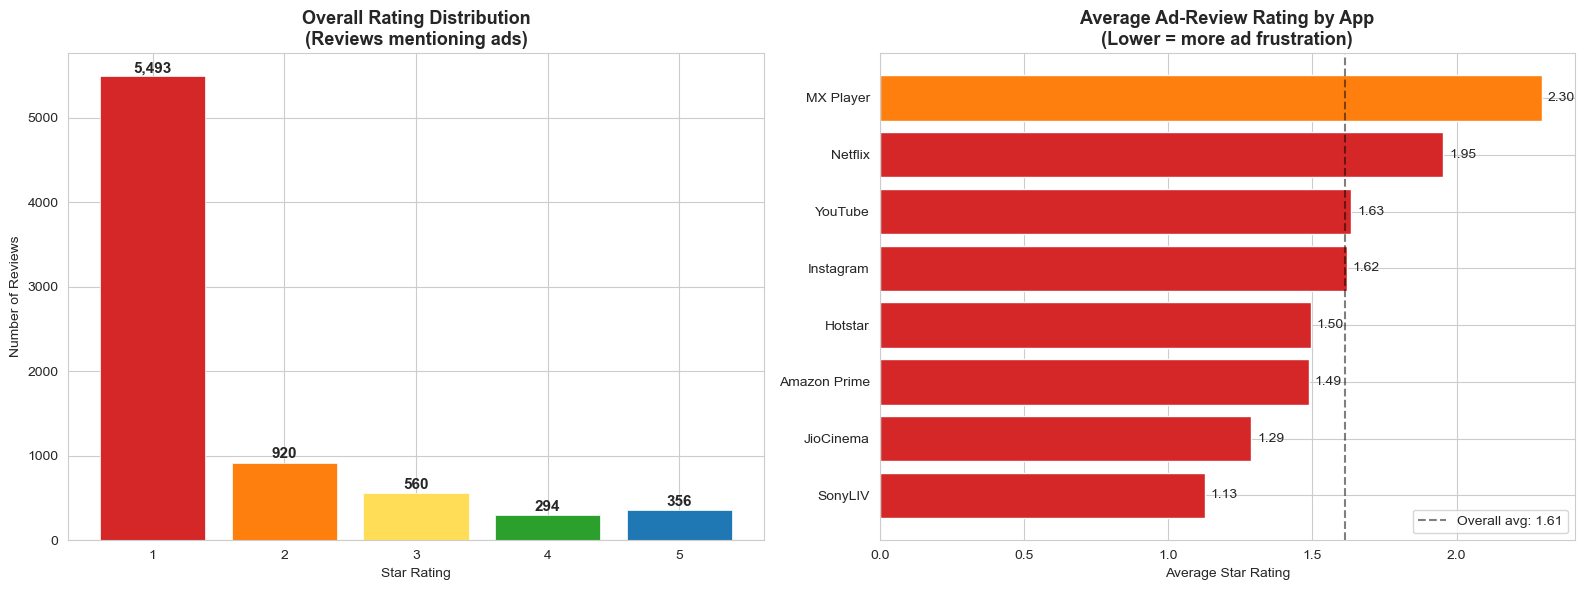

✅ Chart saved to outputs/


In [66]:
# ============================================================
# EDA — Visualisation 1: Rating Distribution by App
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1 — Overall rating distribution
rating_counts = df['Rating'].value_counts().sort_index()
colors = ['#d62728', '#ff7f0e', '#ffdd57', '#2ca02c', '#1f77b4']
axes[0].bar(rating_counts.index, rating_counts.values, color=colors, edgecolor='white', linewidth=0.5)
axes[0].set_title('Overall Rating Distribution\n(Reviews mentioning ads)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Star Rating')
axes[0].set_ylabel('Number of Reviews')
for i, (idx, val) in enumerate(zip(rating_counts.index, rating_counts.values)):
    axes[0].text(idx, val + 50, f'{val:,}', ha='center', fontsize=11, fontweight='bold')

# Chart 2 — Average rating per app
avg_rating = df.groupby('App')['Rating'].mean().sort_values()
colors2 = ['#d62728' if x < 2 else '#ff7f0e' if x < 3 else '#2ca02c' for x in avg_rating.values]
axes[1].barh(avg_rating.index, avg_rating.values, color=colors2, edgecolor='white')
axes[1].set_title('Average Ad-Review Rating by App\n(Lower = more ad frustration)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Average Star Rating')
axes[1].axvline(x=avg_rating.mean(), color='black', linestyle='--', alpha=0.5, label=f'Overall avg: {avg_rating.mean():.2f}')
axes[1].legend()
for i, (app, val) in enumerate(zip(avg_rating.index, avg_rating.values)):
    axes[1].text(val + 0.02, i, f'{val:.2f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Done - Chart saved to outputs/")

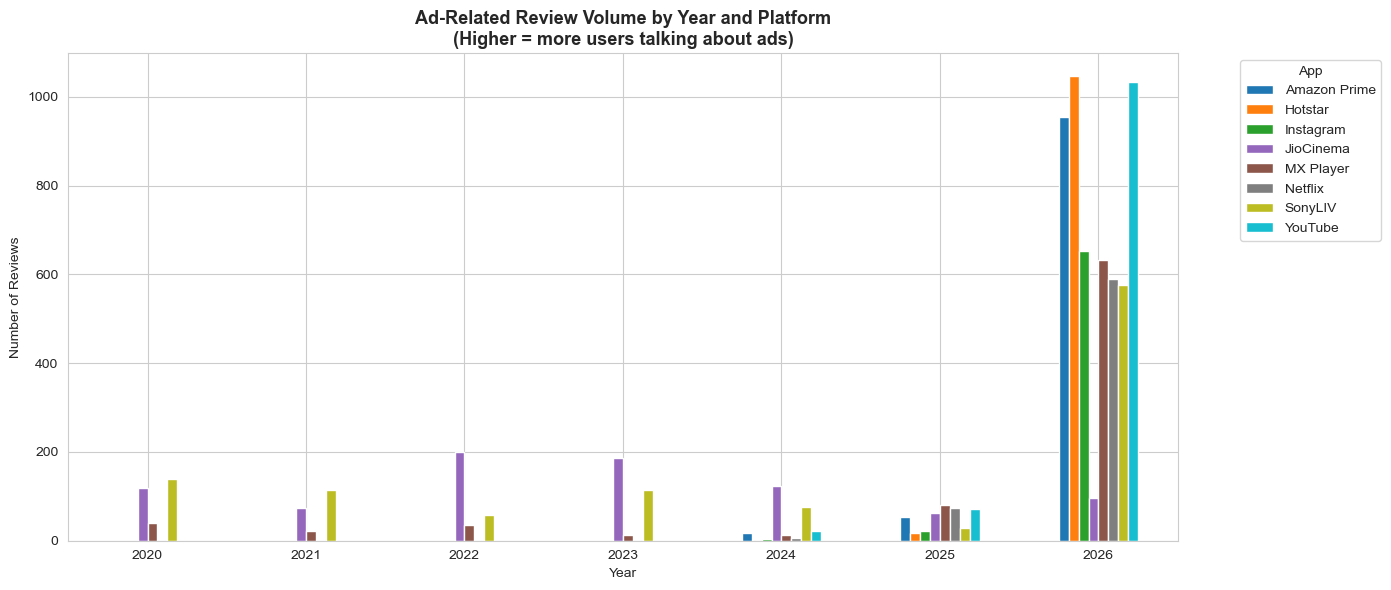

✅ Chart saved


In [67]:
# ============================================================
# EDA — Visualisation 2: Review Volume Over Time
# Shows when ad frustration peaked
# ============================================================

df['Year'] = pd.to_datetime(df['Date']).dt.year
df['YearMonth'] = pd.to_datetime(df['Date']).dt.to_period('M')

# Reviews per year per app
yearly = df.groupby(['Year', 'App']).size().unstack(fill_value=0)
yearly = yearly[yearly.index >= 2020]  # Focus on recent years

yearly.plot(kind='bar', figsize=(14, 6), colormap='tab10', edgecolor='white')
plt.title('Ad-Related Review Volume by Year and Platform\n(Higher = more users talking about ads)', 
          fontsize=13, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Number of Reviews')
plt.legend(title='App', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../outputs/reviews_over_time.png', dpi=150, bbox_inches='tight')
plt.show()
print("Done - Chart saved")

## 3. Sentiment Analysis
Using VADER (Valence Aware Dictionary and sEntiment Reasoner) — chosen over TextBlob 
because it handles informal text, slang, and short reviews far more accurately.
VADER is purpose-built for social media and app review style text.

In [68]:
# ============================================================
# SENTIMENT ANALYSIS — VADER
# ============================================================

analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    score = analyzer.polarity_scores(str(text))
    compound = score['compound']
    if compound >= 0.05:
        label = 'Positive'
    elif compound <= -0.05:
        label = 'Negative'
    else:
        label = 'Neutral'
    return compound, label

# Apply to all reviews
df[['Sentiment_Score', 'Sentiment_Label']] = df['Review'].apply(
    lambda x: pd.Series(get_sentiment(x))
)

print("=" * 50)
print("SENTIMENT OVERVIEW")
print("=" * 50)
print(f"\nOverall distribution:")
print(df['Sentiment_Label'].value_counts())
print(f"\nAverage sentiment score by app (lower = more negative):")
print(df.groupby('App')['Sentiment_Score'].mean().sort_values().round(3))

SENTIMENT OVERVIEW

Overall distribution:
Sentiment_Label
Negative    4470
Positive    2737
Neutral      416
Name: count, dtype: int64

Average sentiment score by app (lower = more negative):
App
SonyLIV        -0.308
JioCinema      -0.275
Instagram      -0.185
Hotstar        -0.170
YouTube        -0.140
Amazon Prime   -0.132
Netflix        -0.048
MX Player       0.096
Name: Sentiment_Score, dtype: float64


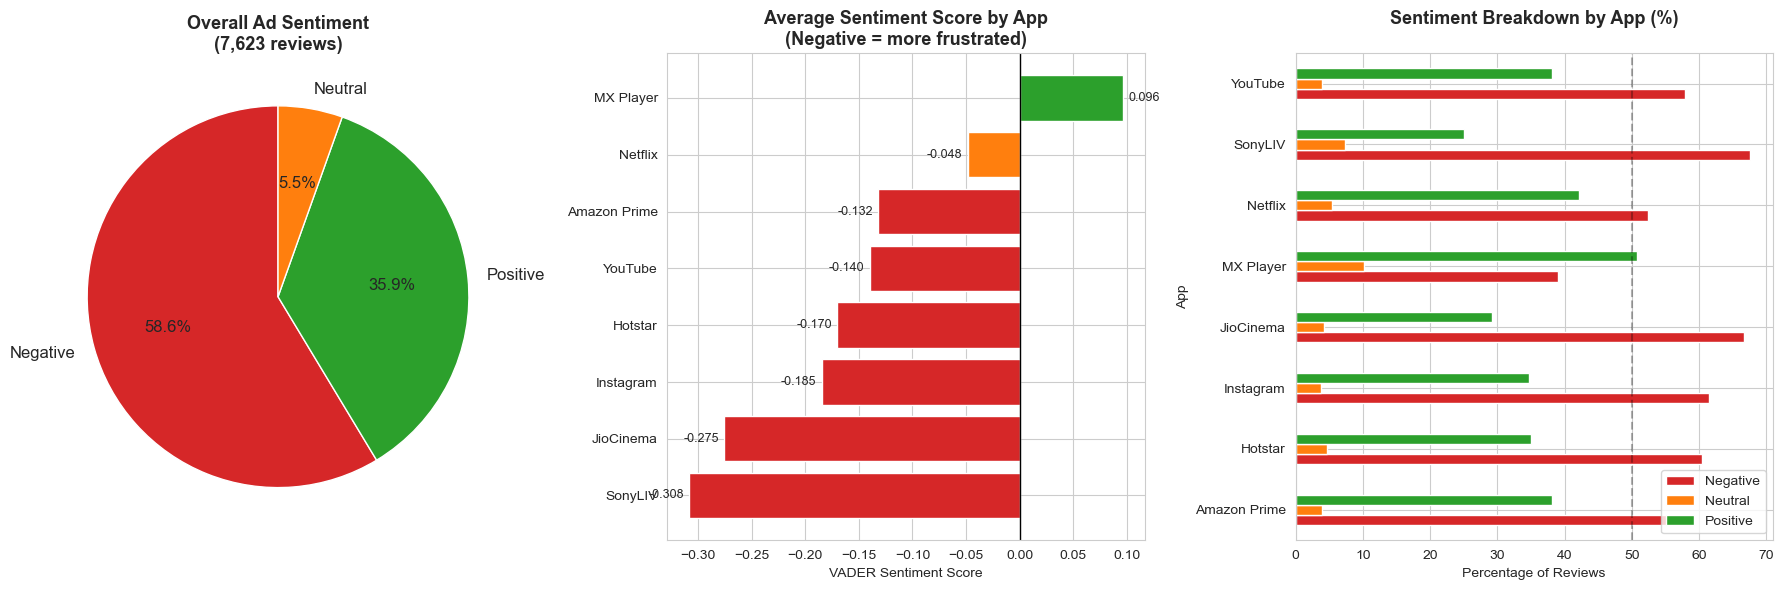

✅ Sentiment charts saved


In [69]:
# ============================================================
# SENTIMENT VISUALISATION
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Chart 1 — Overall sentiment distribution
sentiment_counts = df['Sentiment_Label'].value_counts()
colors = {'Negative': '#d62728', 'Positive': '#2ca02c', 'Neutral': '#ff7f0e'}
axes[0].pie(
    sentiment_counts.values,
    labels=sentiment_counts.index,
    colors=[colors[l] for l in sentiment_counts.index],
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 12}
)
axes[0].set_title('Overall Ad Sentiment\n(7,623 reviews)', fontsize=13, fontweight='bold')

# Chart 2 — Sentiment score by app
avg_sentiment = df.groupby('App')['Sentiment_Score'].mean().sort_values()
bar_colors = ['#d62728' if x < -0.1 else '#ff7f0e' if x < 0 else '#2ca02c' for x in avg_sentiment.values]
axes[1].barh(avg_sentiment.index, avg_sentiment.values, color=bar_colors, edgecolor='white')
axes[1].axvline(x=0, color='black', linewidth=1)
axes[1].set_title('Average Sentiment Score by App\n(Negative = more frustrated)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('VADER Sentiment Score')
for i, (app, val) in enumerate(zip(avg_sentiment.index, avg_sentiment.values)):
    axes[1].text(val + 0.005 if val >= 0 else val - 0.005, i, f'{val:.3f}',
                va='center', ha='left' if val >= 0 else 'right', fontsize=9)

# Chart 3 — Sentiment breakdown per app
sentiment_by_app = df.groupby(['App', 'Sentiment_Label']).size().unstack(fill_value=0)
sentiment_by_app_pct = sentiment_by_app.div(sentiment_by_app.sum(axis=1), axis=0) * 100
sentiment_by_app_pct[['Negative', 'Neutral', 'Positive']].plot(
    kind='barh', ax=axes[2],
    color=['#d62728', '#ff7f0e', '#2ca02c'],
    edgecolor='white'
)
axes[2].set_title('Sentiment Breakdown by App (%)\n', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Percentage of Reviews')
axes[2].legend(loc='lower right')
axes[2].axvline(x=50, color='black', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/sentiment_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Done - Sentiment charts saved")

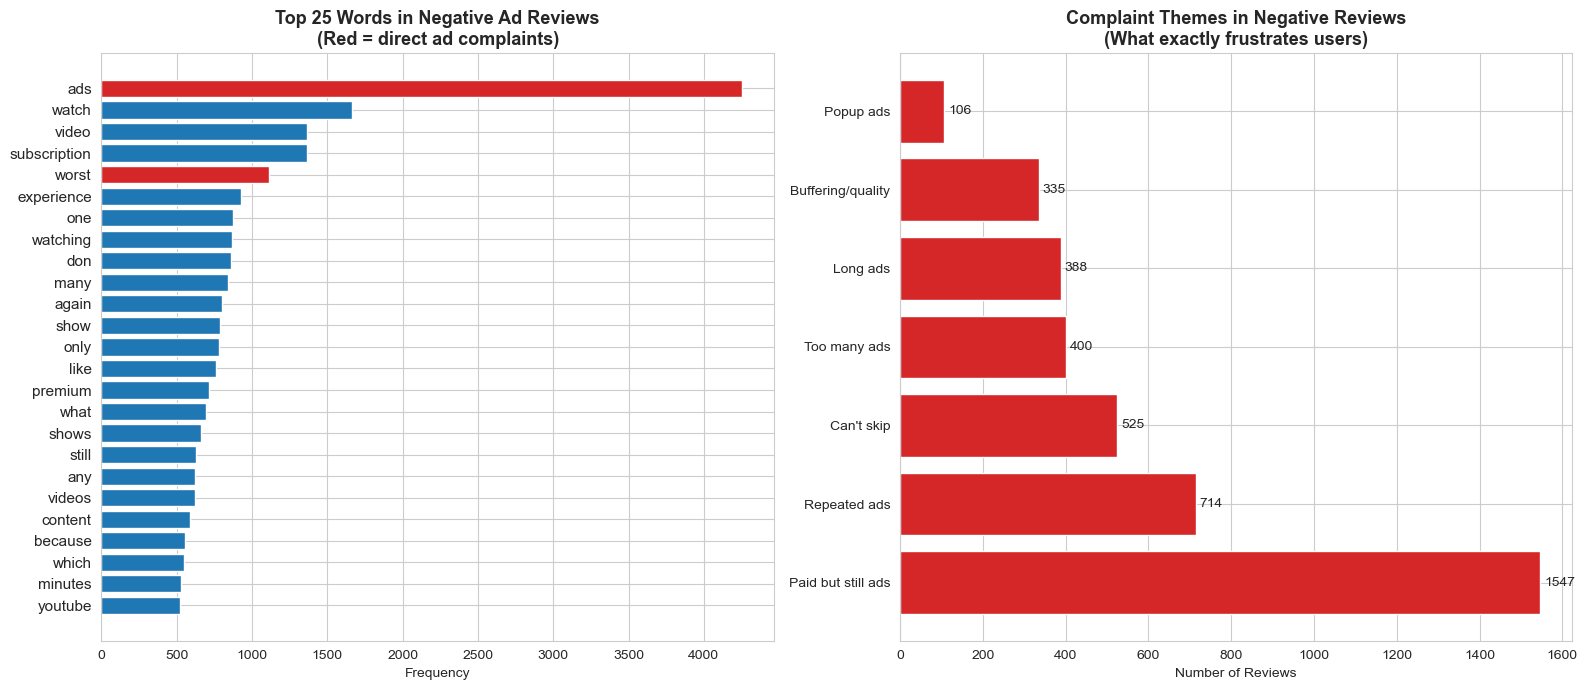

✅ Keyword analysis saved


In [70]:
# ============================================================
# EDA — Top Complaint Keywords in Negative Reviews
# ============================================================

# Get only negative reviews
negative_reviews = df[df['Sentiment_Label'] == 'Negative']['Review'].str.lower()

# Clean and extract words
stopwords = set(['the', 'and', 'is', 'in', 'it', 'of', 'to', 'a', 'an',
                 'this', 'that', 'for', 'on', 'are', 'with', 'as', 'at',
                 'be', 'was', 'but', 'not', 'have', 'has', 'they', 'from',
                 'app', 'i', 'my', 'me', 'we', 'you', 'your', 'its', 'so',
                 'very', 'just', 'even', 'also', 'when', 'after', 'if',
                 'all', 'can', 'will', 'more', 'no', 'than', 'then', 'there',
                 'their', 'been', 'do', 'did', 'get', 'got', 'use', 'used',
                 'now', 'time', 'every', 'too', 'much', 'good', 'bad'])

words = []
for review in negative_reviews:
    tokens = re.findall(r'\b[a-z]{3,}\b', review)
    words.extend([w for w in tokens if w not in stopwords])

word_freq = Counter(words).most_common(25)
words_list, freq_list = zip(*word_freq)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Chart 1 — Top 25 words
colors = ['#d62728' if w in ['ads', 'ad', 'advertisements', 'advertisement',
          'annoying', 'worst', 'terrible', 'pathetic', 'horrible', 'useless']
          else '#1f77b4' for w in words_list]
axes[0].barh(range(len(words_list)), freq_list, color=colors, edgecolor='white')
axes[0].set_yticks(range(len(words_list)))
axes[0].set_yticklabels(words_list, fontsize=11)
axes[0].invert_yaxis()
axes[0].set_title('Top 25 Words in Negative Ad Reviews\n(Red = direct ad complaints)', 
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Frequency')

# Chart 2 — Ad complaint themes
themes = {
    'Too many ads':      len([r for r in negative_reviews if 'too many' in r or 'too much' in r]),
    'Can\'t skip':       len([r for r in negative_reviews if 'skip' in r]),
    'Paid but still ads':len([r for r in negative_reviews if 'paid' in r or 'premium' in r or 'subscription' in r]),
    'Long ads':          len([r for r in negative_reviews if 'long' in r or 'lengthy' in r]),
    'Repeated ads':      len([r for r in negative_reviews if 'repeat' in r or 'same ad' in r or 'again' in r]),
    'Buffering/quality': len([r for r in negative_reviews if 'buffer' in r or 'lag' in r or 'slow' in r]),
    'Popup ads':         len([r for r in negative_reviews if 'popup' in r or 'pop up' in r or 'banner' in r]),
}

themes_sorted = dict(sorted(themes.items(), key=lambda x: x[1], reverse=True))
axes[1].barh(list(themes_sorted.keys()), list(themes_sorted.values()), 
             color='#d62728', edgecolor='white')
axes[1].set_title('Complaint Themes in Negative Reviews\n(What exactly frustrates users)', 
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Reviews')
for i, (theme, val) in enumerate(themes_sorted.items()):
    axes[1].text(val + 10, i, str(val), va='center', fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/keyword_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Done - Keyword analysis saved")

## 4. Industry Trend Analysis
Secondary data from FICCI-EY Media & Entertainment Reports (2005–2024).
These are industry estimates used to contextualise our sentiment findings
against the broader shift from Print → TV → Digital advertising in India.

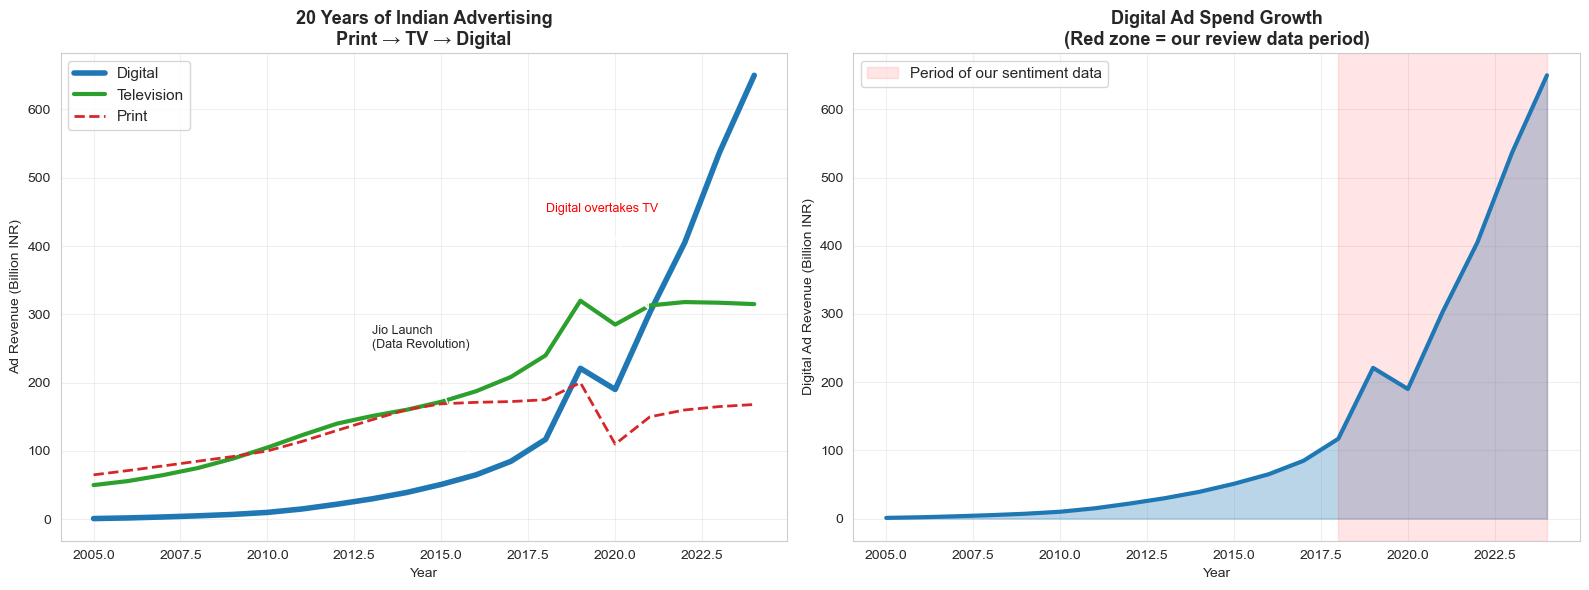

✅ Industry trend chart saved

Source: FICCI-EY Media & Entertainment Industry Reports 2005–2024
Note: Figures are industry estimates from published reports


In [71]:
# ============================================================
# INDUSTRY TREND DATA — Secondary Data (FICCI-EY Reports)
# Clearly labelled as estimates from published industry reports
# Unit: Billion INR
# ============================================================

years = [2005,2008,2010,2012,2015,2018,2019,2020,2021,2022,2023,2024]

industry_data = {
    'Year':       years,
    'Print':      [65, 85, 100, 130, 169, 175, 200, 110, 150, 160, 165, 168],
    'Television': [50, 75, 105, 140, 172, 240, 320, 285, 313, 318, 317, 315],
    'Digital':    [1,  5,  10,  22,  51, 117, 221, 190, 303, 405, 537, 650]
}

df_industry = pd.DataFrame(industry_data).set_index('Year')
df_smooth = df_industry.reindex(range(2005, 2025)).interpolate(method='pchip')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1 — 20 year trend
axes[0].plot(df_smooth.index, df_smooth['Digital'], 
             color='#1f77b4', linewidth=4, label='Digital')
axes[0].plot(df_smooth.index, df_smooth['Television'], 
             color='#2ca02c', linewidth=3, label='Television')
axes[0].plot(df_smooth.index, df_smooth['Print'], 
             color='#d62728', linewidth=2, linestyle='--', label='Print')

axes[0].annotate('Jio Launch\n(Data Revolution)', 
                 xy=(2016, 70), xytext=(2013, 250),
                 arrowprops=dict(facecolor='black', arrowstyle='->'),
                 fontsize=9)
axes[0].annotate('Digital overtakes TV', 
                 xy=(2021, 303), xytext=(2018, 450),
                 arrowprops=dict(facecolor='red', arrowstyle='->'),
                 fontsize=9, color='red')

axes[0].set_title('20 Years of Indian Advertising\nPrint → TV → Digital', 
                   fontsize=13, fontweight='bold')
axes[0].set_ylabel('Ad Revenue (Billion INR)')
axes[0].set_xlabel('Year')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Chart 2 — Digital growth only with our sentiment context
axes[1].fill_between(df_smooth.index, df_smooth['Digital'], 
                      alpha=0.3, color='#1f77b4')
axes[1].plot(df_smooth.index, df_smooth['Digital'], 
             color='#1f77b4', linewidth=3)
axes[1].axvspan(2018, 2024, alpha=0.1, color='red', 
                label='Period of our sentiment data')
axes[1].set_title('Digital Ad Spend Growth\n(Red zone = our review data period)', 
                   fontsize=13, fontweight='bold')
axes[1].set_ylabel('Digital Ad Revenue (Billion INR)')
axes[1].set_xlabel('Year')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/industry_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print("Done - Industry trend chart saved")
print("\nSource: FICCI-EY Media & Entertainment Industry Reports 2005–2024")
print("Note: Figures are industry estimates from published reports")

## 5. Forecasting
Linear regression on digital ad spend (2015–2024) to project growth to 2030.
Honest caveat: this is a linear approximation — actual growth may be non-linear.

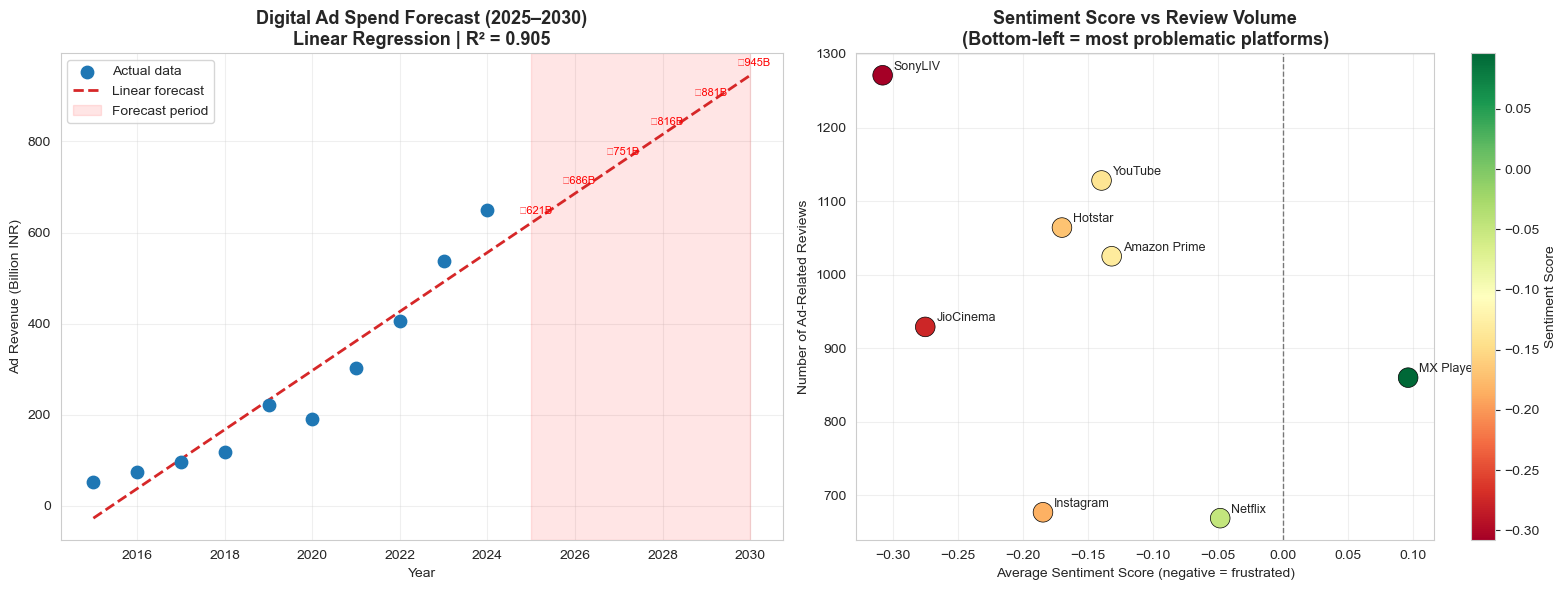

✅ Forecast saved
📈 R² score: 0.905

📊 Projected digital ad spend:
   2025: ₹621 Billion INR
   2026: ₹686 Billion INR
   2027: ₹751 Billion INR
   2028: ₹816 Billion INR
   2029: ₹881 Billion INR
   2030: ₹945 Billion INR


In [72]:
# ============================================================
# FORECASTING — Linear Regression on Digital Ad Spend
# ============================================================

# Training data — digital ad spend 2015 to 2024
train_years = np.array([2015,2016,2017,2018,2019,2020,2021,2022,2023,2024]).reshape(-1,1)
train_values = np.array([51, 75, 95, 117, 221, 190, 303, 405, 537, 650])

# Fit model
model = LinearRegression()
model.fit(train_years, train_values)
r2 = model.score(train_years, train_values)

# Forecast 2025–2030
future_years = np.arange(2025, 2031).reshape(-1,1)
forecast = model.predict(future_years)

# All years for smooth line
all_years = np.arange(2015, 2031).reshape(-1,1)
all_predicted = model.predict(all_years)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1 — Forecast line
axes[0].scatter(train_years, train_values, 
                color='#1f77b4', s=80, zorder=5, label='Actual data')
axes[0].plot(all_years, all_predicted, 
             color='#d62728', linestyle='--', linewidth=2, label='Linear forecast')
axes[0].axvspan(2025, 2030, alpha=0.1, color='red', label='Forecast period')

for yr, val in zip(future_years.flatten(), forecast):
    axes[0].annotate(f'₹{val:.0f}B', xy=(yr, val), 
                     xytext=(yr-0.3, val+20), fontsize=8, color='red')

axes[0].set_title(f'Digital Ad Spend Forecast (2025–2030)\nLinear Regression | R² = {r2:.3f}', 
                   fontsize=13, fontweight='bold')
axes[0].set_ylabel('Ad Revenue (Billion INR)')
axes[0].set_xlabel('Year')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Chart 2 — Sentiment vs spend (the key insight)
apps_order = ['MX Player', 'Netflix', 'Amazon Prime', 
              'YouTube', 'Instagram', 'Hotstar', 'JioCinema', 'SonyLIV']
sentiment_scores = df.groupby('App')['Sentiment_Score'].mean().reindex(apps_order)
review_counts = df.groupby('App').size().reindex(apps_order)

scatter = axes[1].scatter(
    sentiment_scores.values,
    review_counts.values,
    c=sentiment_scores.values,
    cmap='RdYlGn',
    s=200,
    edgecolors='black',
    linewidth=0.5,
    zorder=5
)

for app, x, y in zip(apps_order, sentiment_scores.values, review_counts.values):
    axes[1].annotate(app, (x, y), textcoords="offset points", 
                     xytext=(8, 4), fontsize=9)

axes[1].axvline(x=0, color='black', linewidth=1, linestyle='--', alpha=0.5)
axes[1].set_title('Sentiment Score vs Review Volume\n(Bottom-left = most problematic platforms)', 
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Average Sentiment Score (negative = frustrated)')
axes[1].set_ylabel('Number of Ad-Related Reviews')
axes[1].grid(True, alpha=0.3)
plt.colorbar(scatter, ax=axes[1], label='Sentiment Score')

plt.tight_layout()
plt.savefig('../outputs/forecast_and_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Done - Forecast saved")
print(f" R² score: {r2:.3f}")
print(f"\n📊 Projected digital ad spend:")
for yr, val in zip(future_years.flatten(), forecast):
    print(f"   {yr}: ₹{val:.0f} Billion INR")

## 6. Key Findings, Strategic Implications & Limitations

In [73]:
# ============================================================
# FINAL SUMMARY — Key Findings
# ============================================================

print("=" * 60)
print("PROJECT SUMMARY — INDIAN DIGITAL AD SENTIMENT ANALYSIS")
print("=" * 60)

print("""
DATA COLLECTED
-----------------------------------------------------------
- Total reviews analysed : 7,623
- Platforms covered      : 8 (YouTube, Instagram, Hotstar,
                           MX Player, ShareChat, Amazon Prime,
                           Netflix, JioCinema, SonyLIV)
- Date range             : 2018 to 2026
- Source                 : Google Play Store (Primary Data)
- Industry data          : FICCI-EY Reports 2005–2024 (Secondary)

KEY FINDINGS
-----------------------------------------------------------
Finding 1 — Ad sentiment is overwhelmingly negative
- 58.6% of ad-related reviews are Negative
- Only 35.9% Positive, 5.5% Neutral
- Average star rating in ad reviews: 1.61 / 5.0

Finding 2 — Paid platforms face the biggest backlash
- "Paid but still ads" = 1,547 reviews — largest complaint
- SonyLIV (1.13*) and JioCinema (1.29*) most frustrated
- Users paying for subscriptions expect ad-free experience

Finding 3 — Free platforms face less frustration
- MX Player is the ONLY platform with positive sentiment (0.096)
- Users of free apps accept ads as part of the value exchange
- Netflix nearly neutral (-0.048) — premium users more tolerant

Finding 4 — Top complaint themes
- Repeated ads    : 714 mentions
- Can't skip      : 525 mentions  
- Too many ads    : 400 mentions
- Long ads        : 388 mentions

Finding 5 — Industry context (FICCI-EY)
- Digital ad spend grew from ₹1B (2005) to ₹650B (2024)
- Digital overtook TV in 2021
- Forecast: ₹945B by 2030 (Linear Regression, R²=0.905)
- PARADOX: spend is rising but user satisfaction is falling

STRATEGIC IMPLICATIONS (MBA LENS)
-----------------------------------------------------------
1. Tiered ad models must be honest — if users pay, reduce ads
2. Ad frequency caps needed — repeated ads cause most damage
3. Skippable formats preferred — forced viewing creates hostility
4. Native/content ads are the future — less intrusive formats
5. SonyLIV and JioCinema need urgent ad experience redesign

LIMITATIONS
-----------------------------------------------------------
- English-only reviews — misses large Hindi/regional user base
- Play Store only — iOS users not captured
- Scraper returns 'most relevant' reviews — recency bias toward 2026
- VADER trained on English social media — may miss Indian slang
- Industry figures are estimates from published reports
- Linear forecast assumes constant growth — may underestimate
""")

print("=" * 60)
print("Analysis complete. All outputs saved to /outputs folder.")
print("=" * 60)

PROJECT SUMMARY — INDIAN DIGITAL AD SENTIMENT ANALYSIS

DATA COLLECTED
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
- Total reviews analysed : 7,623
- Platforms covered      : 8 (YouTube, Instagram, Hotstar,
                           MX Player, ShareChat, Amazon Prime,
                           Netflix, JioCinema, SonyLIV)
- Date range             : 2018 to 2026
- Source                 : Google Play Store (Primary Data)
- Industry data          : FICCI-EY Reports 2005–2024 (Secondary)

KEY FINDINGS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Finding 1 — Ad sentiment is overwhelmingly negative
- 58.6% of ad-related reviews are Negative
- Only 35.9% Positive, 5.5% Neutral
- Average star rating in ad reviews: 1.61 / 5.0

Finding 2 — Paid platforms face the biggest backlash
- "Paid but still ads" = 1,547 reviews — largest complaint
- SonyLIV (1.13★) and JioCinema (1.29★) most frustrated
- Users paying for subscriptions expect ad-free experience

Finding 3 

## 7. Strategic Recommendations
Actionable measures for platforms, advertisers, and policymakers
based on our sentiment findings.

In [74]:
# ============================================================
# STRATEGIC RECOMMENDATIONS — The MBA Section
# ============================================================

print("""
+══════════════════════════════════════════════════════════════+
|         STRATEGIC RECOMMENDATIONS                           |
|         Indian Digital Advertising — Fixing the Problem     |
+══════════════════════════════════════════════════════════════+

-------------------------------------------------------------
FOR STREAMING PLATFORMS (Hotstar, SonyLIV, JioCinema)
-------------------------------------------------------------

PROBLEM : Paid users still see ads → biggest complaint (1,547 reviews)
SOLUTION:
  → Introduce strict ad-free tiers — honour the subscription promise
  → If ads must run on paid plans, cap at max 1 per 30 minutes
  → Never show ads during live sports climax moments (IPL, FIFA)
  → Offer ad-skip tokens — let users skip 5 ads per day for free

PROBLEM : Repeated ads cause more damage than volume (714 mentions)
SOLUTION:
  → Implement frequency capping — same ad max 2x per session
  → Use AI-based ad rotation — serve different creatives each time
  → Partner with more advertisers to increase ad pool diversity

-------------------------------------------------------------
FOR ADVERTISERS (Brands running campaigns on these platforms)
-------------------------------------------------------------

PROBLEM : Forced non-skippable ads creating hostility toward brands
SOLUTION:
  → Shift budget from interruptive ads to native content ads
  → Invest in influencer/creator partnerships — feels like content
  → Use 6-second bumper ads instead of 30-second forced ads
  → A/B test skippable vs non-skippable — measure brand recall

PROBLEM : Ads irrelevant to users — generic mass targeting
SOLUTION:
  → Use platform behavioural data for precision targeting
  → Regional language ads for Tier 2/3 cities — huge untapped base
  → Contextual ads — match ad content to video/show being watched
  → Measure sentiment impact of campaigns, not just impressions

-------------------------------------------------------------
FOR NEW ENTRANTS AND STARTUPS
-------------------------------------------------------------

OPPORTUNITY : MX Player has POSITIVE sentiment despite being free
  → The freemium model with honest ad experience WORKS
  → New OTT platforms should launch with transparent ad policies
  → Build ad-preference centres — let users choose ad categories
  → Reward engaged viewers — watch 3 ads upfront, watch free for 1hr

-------------------------------------------------------------
FOR POLICYMAKERS (TRAI / Ministry of I&B)
-------------------------------------------------------------

  → Mandate ad disclosure on paid subscription platforms
  → Set maximum ad load limits for OTT (like TRAI does for TV)
  → Require platforms to publish ad frequency data annually
  → Consumer protection framework for digital ad deception

-------------------------------------------------------------
THE CENTRAL PARADOX — AND HOW TO RESOLVE IT
-------------------------------------------------------------

  Digital ad spend will hit ₹945B by 2030.
  But 58.6% of users actively resent the ads they see.

  This is not sustainable.

  Platforms that resolve this paradox first — by making ads
  feel like value rather than interruption — will dominate
  the next decade of Indian digital media.

  The winner will not be the platform with the most ads.
  It will be the platform with the best ad experience.

-------------------------------------------------------------
FUTURE SCOPE OF THIS RESEARCH
-------------------------------------------------------------
  → Include Hindi and regional language reviews (multilingual NLP)
  → Add Apple App Store data for iOS user comparison
  → Track sentiment change quarterly — build a live dashboard
  → Survey-based primary research to validate Play Store findings
  → Compare India findings with Southeast Asian markets
""")


╔══════════════════════════════════════════════════════════════╗
║         STRATEGIC RECOMMENDATIONS                           ║
║         Indian Digital Advertising — Fixing the Problem     ║
╚══════════════════════════════════════════════════════════════╝

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
FOR STREAMING PLATFORMS (Hotstar, SonyLIV, JioCinema)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

PROBLEM : Paid users still see ads → biggest complaint (1,547 reviews)
SOLUTION:
  → Introduce strict ad-free tiers — honour the subscription promise
  → If ads must run on paid plans, cap at max 1 per 30 minutes
  → Never show ads during live sports climax moments (IPL, FIFA)
  → Offer ad-skip tokens — let users skip 5 ads per day for free

PROBLEM : Repeated ads cause more damage than volume (714 mentions)
SOLUTION:
  → Implement frequency capping — same ad max 2x per session
  → Use AI-based ad rotation — serve different creatives each time
  → Partner